# グラフ彩色問題

こちらでは、[Lucas, 2014, "Ising formulations of many NP problems"](https://doi.org/10.3389/fphy.2014.00005)の 6.1. Graph Coloring を OpenJij と [JijModeling](https://jij-inc-jijmodeling-tutorials-ja.readthedocs-hosted.com/ja/latest/introduction.html)、そして ommx-openjij-adapter を用いて解く方法をご紹介します。

## 概要: グラフ彩色問題とは

グラフ彩色問題とは、あるグラフ上の辺で繋がれた頂点どうしを異なる色になるように彩色する問題です。NP完全な問題として知られています。

### 具体例

下図のように6個の頂点といくつかの辺からなる無向グラフが与えられたとしましょう。

![](../../../assets/graph_coloring_01.png)

これを3色で全ての頂点を塗り分けると以下のようになります。

![](../../../assets/graph_coloring_02.png)

全ての辺において、その両端に位置する頂点は異なる色で塗り分けられていることがわかります。

### 問題の一般化

それではこの問題を一般化し、数式で表現してみましょう。無向グラフ$G = (V, E)$を、辺で結ばれた頂点の色が重複しないように$N$色で塗り分けることを考えます。
頂点の色分けをバイナリ変数$x_{v, n}$で表すことにします。$v$番目の頂点を$n$の色で塗り分けるとき、$x_{v, n} = 1$、それ以外では$x_{v, n} = 0$となります。  

**制約: 頂点はどれか一色で塗り分けなければならない**

例えば、青色と緑色の2色で1つの頂点を塗ることは許されません。これを数式で表現すると、以下のようになります。


$$
\nonumber
\sum_{n=0}^{N-1} x_{v, n} = 1 \quad (\forall v \in V) \tag{1}
$$

**目的関数: 同じ色の頂点を両端に持つ辺の数を最小にする**

グラフ彩色問題の問題設定から、全ての辺の両端の頂点が異なる色で塗り分けられる必要があります。これを数式で表現すると

$$
\nonumber
\min \quad \sum_{n=0}^{N-1} \sum_{(uv) \in E} x_{u, n} x_{v, n} \tag{2}
$$

ここで、$E$ はグラフ $G$ の辺集合です。
この目的関数は少し複雑に見えます。
以下の表を見てみましょう。

| $x_{u,n}$ | $x_{v,n}$ | $x_{u,n}x_{v,n}$ |  
|-----------|-----------|------------------|
|     0     |     0     |         0        |
|     0     |     1     |         0        |
|     1     |     0     |         0        |
|     1     |     1     |         1        |

上で定義したように、頂点 $u$ が色 $n$ で塗られているときは $x_{u,n}=1$ です。したがって、上の表から分かるように、$x_{u,n}$ と $x_{v,n}$ がともに 1 のときに限り $x_{u,n}x_{v,n}=1$ となり、それ以外は 0 になります。
全ての辺の両端の頂点が異なる色で塗り分けられているなら、この目的関数値は 0 になります。
つまり、この目的関数はグラフ彩色がどれだけ達成されているかを表す指標になっています。

## JijModelingによる定式化

次に、JijModelingを使って上記の数理モデルを定式化してみましょう。まずは、数理モデルに現れる変数およびパラメーターを定義します。

In [1]:
import jijmodeling as jm

problem = jm.Problem("Graph Coloring")

V = problem.Natural('V')
E = problem.Graph('E')
N = problem.Natural('N')
x = problem.BinaryVar('x', shape=(V, N))

ここでは `V` を頂点の数、`E` をグラフ $G$ の辺集合、`N` を色の数として定義しており、$x_{v,n}$ に相当する2次元のバイナリ変数として `x` を定義しています。

### 制約

式(1)の制約は以下のように定式化しましょう。

In [2]:
problem += problem.Constraint("one-color", lambda v: jm.sum(N, lambda n: x[v, n]) == 1, domain=V)

### 目的関数

式(2)の目的関数は以下のように定式化しましょう。

In [3]:
problem += jm.sum(jm.product(N, E), lambda n, e: x[e[0], n] * x[e[1], n])

実際に定式化された数式をJupyter Notebookで表示してみましょう。

In [4]:
problem

Problem(name="Graph Coloring", sense=MINIMIZE, objective=sum(set((N, E)).map(lambda ((n, e): Tuple[natural, Tuple[natural, natural]]): x[e[0], n] * x[e[1], n])), constraints={one-color: [Constraint(name="one-color", , lambda v: sum(N.map(lambda (n: natural): x[v, n])) == 1, domain=set(V)),],})

## インスタンスの作成

実際にグラフ彩色を行うグラフを設定しましょう。

In [5]:
import networkx as nx

# set the number of vertices
inst_V = 12
# set the number of colors
inst_N = 4
# create a random graph
inst_G = nx.gnp_random_graph(inst_V, 0.4)
# get information of edges
inst_E = [list(edge) for edge in inst_G.edges]
instance_data = {'V': inst_V, 'N': inst_N, 'E': inst_E}

今回は次のようなグラフを塗り分けてみましょう。

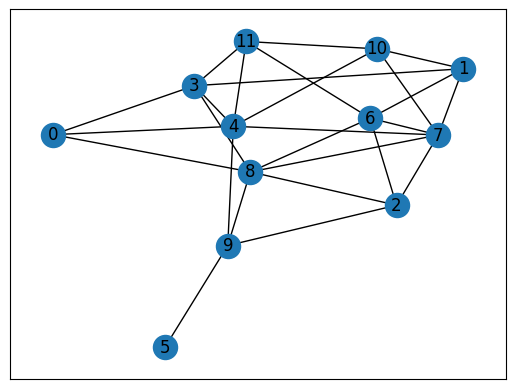

In [6]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(inst_G)
nx.draw_networkx(inst_G, pos=pos, with_labels=True)
plt.show()

## OpenJijによる最適化計算の実行

OpenJijのシミュレーテッド・アニーリングを用いて、最適化問題を解いてみましょう。

In [7]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(instance, num_reads=100).best_feasible_unrelaxed

## 解の可視化

得られた解を用いて、グラフの塗り分けを行ってみましょう。以下のコードで塗り分けられたグラフを見ることができます。

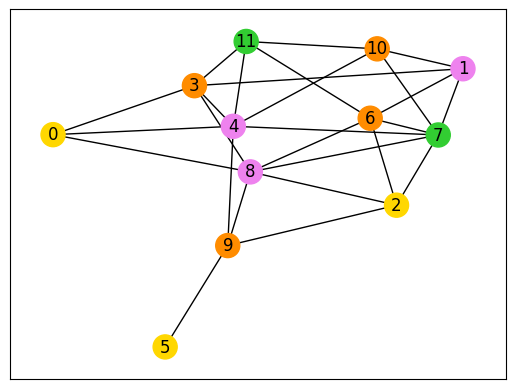

In [8]:
df = best_sample.decision_variables_df
indices = df[(df["name"] == "x") & (df["value"] > 0.5)]["subscripts"].to_list()
node_colors = [-1] * len(indices)
colorlist = ["gold", "violet", "limegreen", "darkorange"]
for i, j in indices:
    node_colors[i] = colorlist[j]
nx.draw_networkx(inst_G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()